# Spectrum Decay From Precomputed Metrics

This notebook reads merged spectrum-only metrics produced offline on the cluster and plots the decay analysis without recomputing eigenspectra.


In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np

METRICS_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/spectrum_parallel/merged')
METRICS_PATH = METRICS_DIR / 'metrics.jsonl'
SUMMARY_PATH = METRICS_DIR / 'summary.json'
RANDOM_SEED = 1

EXCLUDE_UIDS = set()  # e.g. {'test/precalculus/807.json::sample_00'}
APPLY_DECAY_PERCENTILE_FILTER = False
DECAY_PERCENTILE_RANGE = (5.0, 95.0)
DECAY_MAX = 3.0  # e.g. 3.0
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

def load_jsonl(path: Path):
    rows=[]
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

assert METRICS_PATH.exists(), f'missing metrics: {METRICS_PATH}'
samples = load_jsonl(METRICS_PATH)
print('Loaded samples before filtering:', len(samples))
if SUMMARY_PATH.exists():
    print(SUMMARY_PATH.read_text(encoding='utf-8'))

if EXCLUDE_UIDS:
    before = len(samples)
    samples = [s for s in samples if s['uid'] not in EXCLUDE_UIDS]
    print('Excluded by UID:', before - len(samples))

if DECAY_MAX is not None:
    before = len(samples)
    samples = [s for s in samples if float(s['decay_rate']) <= DECAY_MAX]
    print('Excluded by hard decay max:', before - len(samples))

if APPLY_DECAY_PERCENTILE_FILTER:
    decays = np.asarray([s['decay_rate'] for s in samples], dtype=np.float64)
    lo_p, hi_p = DECAY_PERCENTILE_RANGE
    lo, hi = np.percentile(decays, [lo_p, hi_p])
    before = len(samples)
    samples = [s for s in samples if lo <= float(s['decay_rate']) <= hi]
    print(f'Excluded by decay percentile filter [{lo_p}, {hi_p}]:', before - len(samples))
    print('Decay bounds:', float(lo), float(hi))

print('Loaded samples after filtering:', len(samples))


Loaded samples before filtering: 15998
{
  "input_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/spectrum_parallel/shards",
  "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/spectrum_parallel/merged",
  "num_metric_files": 10,
  "merged_rows": 15998,
  "source_summaries": [
    {
      "run_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged",
      "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/spectrum_parallel/shards",
      "metrics_path": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/spectrum_parallel/shards/metrics_shard_00.jsonl",
      "num_shards": 10,
      "shard_index": 0,
      "selected_uids": 1600,
      "processed_rows": 1600,
      "written_rows": 1600,
      "skipped_short": 0,
      "ar_checkpoint": null,
      "ar_device": null,
      "skip_ar": true,
      "use_reasoning_span": true,
    

In [2]:
success = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
decay = np.asarray([s['decay_rate'] for s in samples], dtype=np.float64)
response_length = np.asarray([s['response_length'] for s in samples], dtype=np.float64)
analysis_length = np.asarray([s['analysis_length'] for s in samples], dtype=np.float64)

print('Success decay stats:', {'mean': float(decay[success == 1].mean()), 'std': float(decay[success == 1].std())})
print('Failure decay stats:', {'mean': float(decay[success == 0].mean()), 'std': float(decay[success == 0].std())})


Success decay stats: {'mean': 1.097094958645177, 'std': 0.06249223742160027}
Failure decay stats: {'mean': 1.154277798424286, 'std': 0.0653125807664218}


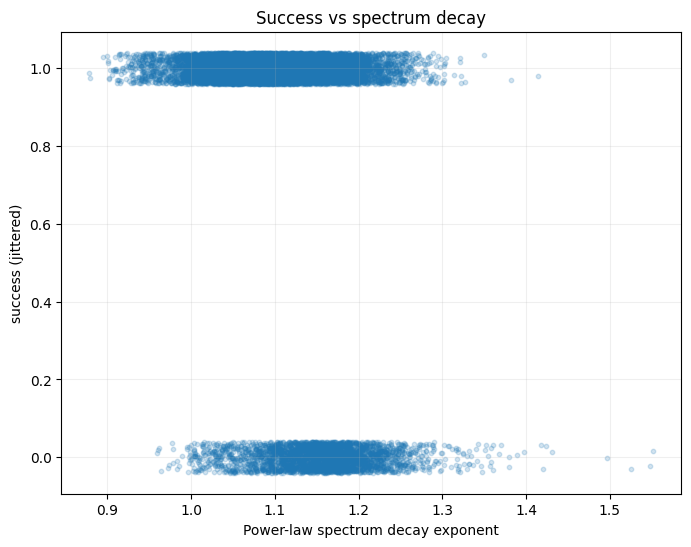

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(decay, success + np.random.uniform(-0.04, 0.04, size=len(samples)), s=10, alpha=0.2)
plt.xlabel('Power-law spectrum decay exponent')
plt.ylabel('success (jittered)')
plt.title('Success vs spectrum decay')
plt.grid(alpha=0.2)
plt.show()


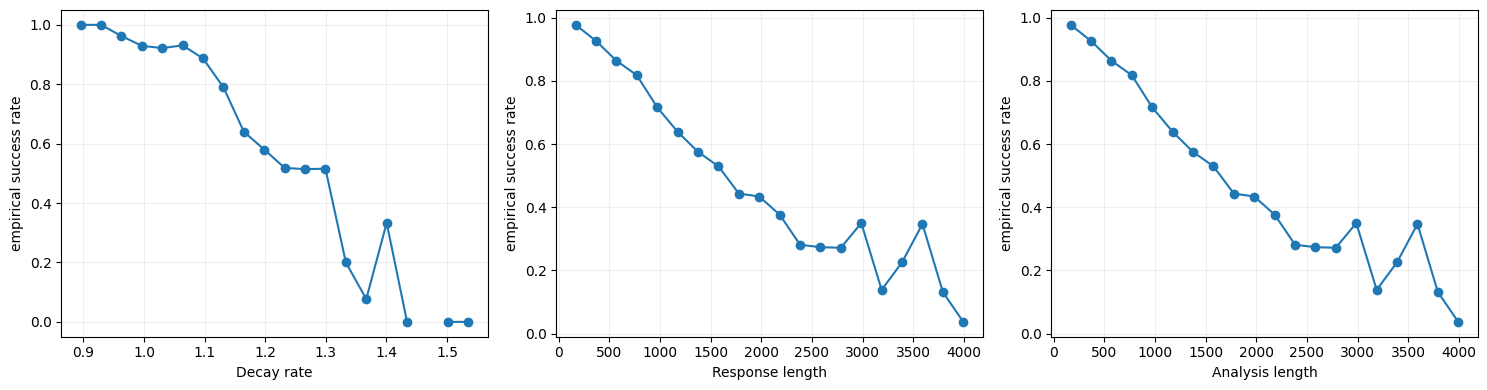

In [4]:
def binned_success_rate(values, success, n_bins=20):
    x = np.asarray(values, dtype=np.float64)
    y = np.asarray(success, dtype=np.float64)
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rates = []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (x >= lo) & (x <= hi) if i == len(edges) - 2 else (x >= lo) & (x < hi)
        rates.append(float(y[mask].mean()) if mask.any() else np.nan)
    return centers, np.asarray(rates)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, vals, label in zip(axes, [decay, response_length, analysis_length], ['Decay rate','Response length','Analysis length']):
    centers, rates = binned_success_rate(vals, success, n_bins=20)
    ax.plot(centers, rates, marker='o')
    ax.set_xlabel(label)
    ax.set_ylabel('empirical success rate')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


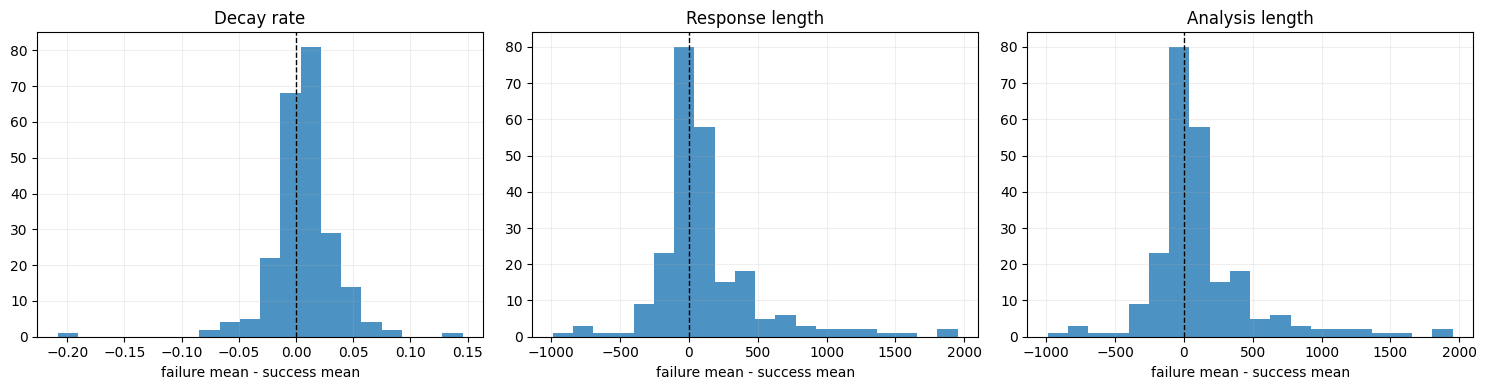

In [5]:
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

paired_decay = []
paired_resp = []
paired_analysis = []
for qid, group in by_question.items():
    succ = [x for x in group if x['success']]
    fail = [x for x in group if not x['success']]
    if not succ or not fail:
        continue
    paired_decay.append(float(np.mean([x['decay_rate'] for x in fail]) - np.mean([x['decay_rate'] for x in succ])))
    paired_resp.append(float(np.mean([x['response_length'] for x in fail]) - np.mean([x['response_length'] for x in succ])))
    paired_analysis.append(float(np.mean([x['analysis_length'] for x in fail]) - np.mean([x['analysis_length'] for x in succ])))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, vals, label in zip(axes, [paired_decay, paired_resp, paired_analysis], ['Decay rate','Response length','Analysis length']):
    ax.hist(np.asarray(vals), bins=20, alpha=0.8)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title(label)
    ax.set_xlabel('failure mean - success mean')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [6]:
def paired_sign_summary(values, name):
    vals = np.asarray(values, dtype=np.float64)
    pos = int(np.sum(vals > 0))
    neg = int(np.sum(vals < 0))
    zero = int(np.sum(vals == 0))
    print(name)
    print('  positive:', pos)
    print('  negative:', neg)
    print('  zero:', zero)
    print('  mean gap:', float(vals.mean()) if vals.size else None)

paired_sign_summary(paired_decay, 'Decay rate')
paired_sign_summary(paired_resp, 'Response length')
paired_sign_summary(paired_analysis, 'Analysis length')


Decay rate
  positive: 145
  negative: 88
  zero: 0
  mean gap: 0.006646567632825924
Response length
  positive: 137
  negative: 95
  zero: 1
  mean gap: 118.120432488414
Analysis length
  positive: 137
  negative: 95
  zero: 1
  mean gap: 118.120432488414
